In [1]:
import sys, os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["JAX_ENABLE_X64"] = "True"
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']=".97"
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']="False"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.95'
os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')
# from jax.config import config
from jax import config
# config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad
#import pyccl as ccl
import pickle as pk
import scipy.interpolate as interp
import warnings

# Suppress RuntimeWarnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import sys, os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["JAX_ENABLE_X64"] = "True"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.95'


# Change the current working directory to the desired path
os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')
# from jax.config import config
from jax import config
# config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad
%matplotlib inline
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
pl.rc('font', family='DejaVu Sans')



In [2]:
# process the catalog to save M200c, R200c from Mvir using colossus
from astropy.io import fits
import colossus
from colossus.cosmology import cosmology as cosmology_colossus
from colossus.lss import mass_function
from colossus.halo import concentration
from colossus.halo import mass_defs
from scipy.ndimage.filters import gaussian_filter1d
import healpy as hp
params = {'w0':-1.0 ,'flat': True, 'H0': 70.0, 'Om0': 0.286, 'Ob0': 0.047, 'sigma8':0.82 ,'ns': 0.96}
cosmology_colossus.addCosmology('myCosmo', params)
cosmology_colossus.setCosmology('myCosmo')
cosmo_colossus = cosmology_colossus.setCosmology('myCosmo')

# hcat_fname = '/mnt/home/spandey/ceph/GODMAX/data/cardinal/halo_input.fits'
id_all = [0,1,2,3,4,5,6,7,19,21,22,23,26]

ra_all, dec_all, redshift_all, M200c_all = [], [], [], []

for id in id_all:
    hcat_fname = f'/mnt/home/spandey/ceph/GODMAX/data/cardinal/halos_y6/Chinchilla-3_halos_lensed.{id}.fits'
    catalog_data = fits.open(hcat_fname)[1].data
    # print(catalog_data.columns)
    rpx, rpy, rpz = catalog_data['PX'], catalog_data['PY'], catalog_data['PZ']


    d2r = np.pi/180.0
    ra = np.arctan2(rpy,rpx)/d2r
    dec = 90.0 - np.arccos(rpz/np.sqrt(rpx*rpx + rpy*rpy + rpz*rpz))/d2r

    redshift = catalog_data['Z']
    M200c = catalog_data['M200c']
    ra_all.append(ra)
    dec_all.append(dec)
    redshift_all.append(redshift)
    M200c_all.append(M200c)

# ra, dec = hp.vec2ang(np.array([x, y, z]), lonlat=True)

ra_all = np.concatenate(ra_all)
dec_all = np.concatenate(dec_all)
redshift_all = np.concatenate(redshift_all)
M200c_all = np.concatenate(M200c_all)



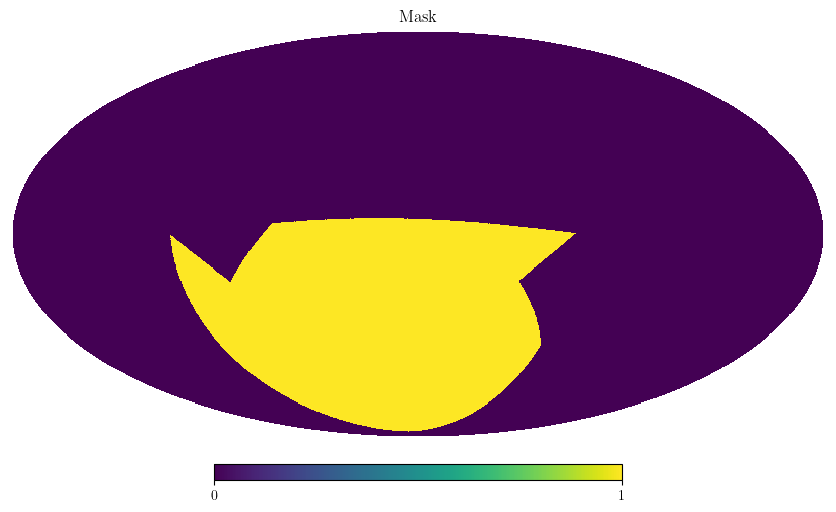

In [3]:
nside = 512
mask = np.zeros(hp.nside2npix(nside))
pix = hp.ang2pix(nside, ra_all, dec_all, lonlat=True)
mask[pix] = 1
hp.mollview(mask, title='Mask', cmap='viridis')
# zh_all = catalog_data['z']
# ra_all = catalog_data['ra']
# dec_all = catalog_data['dec']
# mvir_all = np.array(catalog_data['m200'], dtype=np.float64)


In [4]:
mask_ud = hp.ud_grade(mask, nside_out=4096)




In [5]:
hp.write_map('/mnt/home/spandey/ceph/GODMAX/data/cardinal/mask_tsz_wide.fits', mask_ud, overwrite=True)



setting the output map dtype to [dtype('float64')]


In [ ]:
# z0 = 0.0
# zf = 0.95
# nz = 100
# zedges = np.linspace(z0, zf, nz+1)
# M200c_all = np.zeros_like(mvir_all)
# c200c_all = np.zeros_like(mvir_all)
# for jz in range(nz):
#     z0_jz = zedges[jz]
#     zf_jz = zedges[jz+1]
#     indsel = np.where((zh_all >= z0_jz) & (zh_all < zf_jz))[0]
#     mvir_sel = mvir_all[indsel]
#     zsel = zh_all[indsel]
#     zbar = np.mean(zsel)
#     cvir_sel = concentration.concentration(mvir_sel, 'vir', zbar, model = 'ishiyama21')
#     M200c_sel, R200c_sel, c200c_sel = mass_defs.changeMassDefinition(mvir_sel, cvir_sel, zbar, 'vir', '200c')
#     M200c_all[indsel] = M200c_sel
#     c200c_all[indsel] = c200c_sel



In [6]:
# create a new astropy fits file and save the columns:
# ra, dec, z, M200c, R200c, c200c
# save the file
# hcat_new = fits.HDUList()
# cols = []
# cols.append(fits.Column(name='ra', format='D', array=ra_all))
# cols.append(fits.Column(name='dec', format='D', array=dec_all))
# cols.append(fits.Column(name='z', format='D', array=zh_all))
# cols.append(fits.Column(name='M200c', format='D', array=M200c_all))
# cols.append(fits.Column(name='c200c', format='D', array=c200c_all))
# hcat_new.append(fits.BinTableHDU.from_columns(cols))
# hcat_new.writeto('/mnt/home/spandey/ceph/GODMAX/data/cardinal/halo_input_wR200c.fits', overwrite=True)


hcat_new = fits.HDUList()
cols = []
cols.append(fits.Column(name='ra', format='D', array=ra_all))
cols.append(fits.Column(name='dec', format='D', array=dec_all))
cols.append(fits.Column(name='z', format='D', array=redshift_all))
cols.append(fits.Column(name='M200c', format='D', array=M200c_all))
# cols.append(fits.Column(name='c200c', format='D', array=c200c_all))
hcat_new.append(fits.BinTableHDU.from_columns(cols))
hcat_new.writeto('/mnt/home/spandey/ceph/GODMAX/data/cardinal/halo_input_wide.fits', overwrite=True)




XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   40 / length of dimension 1                          
NAXIS2  =              2813133 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    5 / number of table fields                         
TTYPE1  = 'ra      '                                                            
TFORM1  = 'D       '                                                            
TTYPE2  = 'dec     '                                                            
TFORM2  = 'D       '                                                            
TTYPE3  = 'z       '        

In [4]:
M_halo = np.log10(M200c_all)
redshift = zh_all


In [7]:
full_sky_area = 4*np.pi*(180/np.pi)**2
# print(full_sky_area)
area = 4514.0
fsky = area/full_sky_area



12.69973825704542
12.706039485752756
12.713196672899647
12.718718959649618
12.723160585318821
12.727474466025397
12.73153267588394


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


12.734676838014142


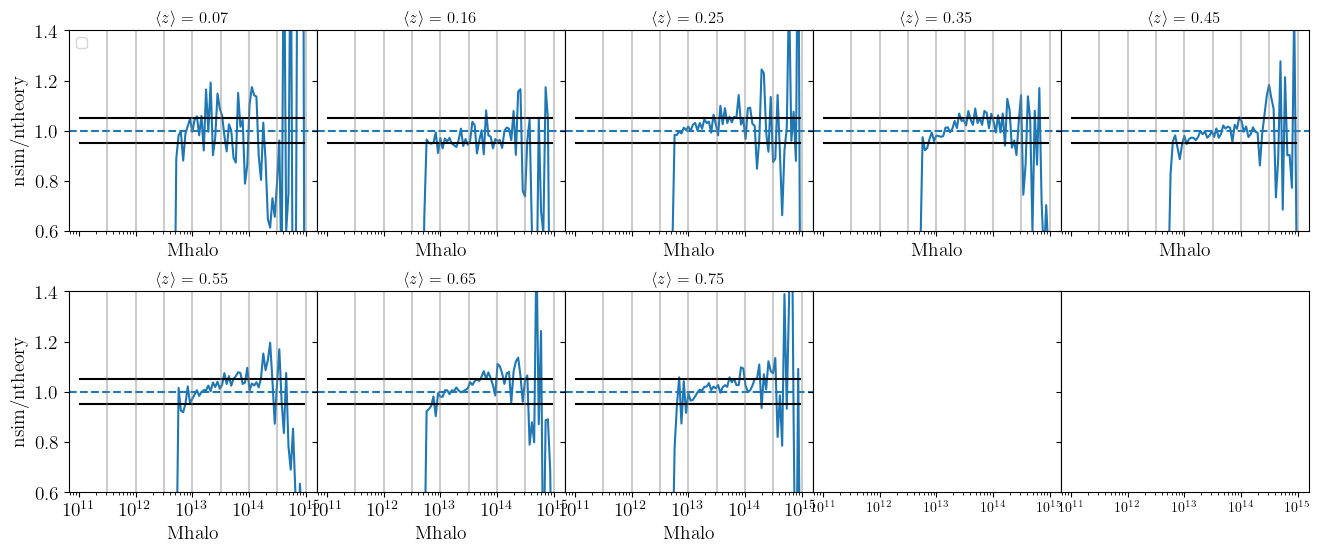

In [10]:
# mvir_all.shape
from colossus.cosmology import cosmology as cosmology_colossus
from colossus.lss import mass_function
from colossus.halo import concentration
from colossus.halo import mass_defs
from scipy.ndimage.filters import gaussian_filter1d
params = {'w0':-1.0 ,'flat': True, 'H0': 70.0, 'Om0': 0.286, 'Ob0': 0.047, 'sigma8':0.82 ,'ns': 0.96}
cosmology_colossus.addCosmology('myCosmo', params)
cosmology_colossus.setCosmology('myCosmo')
cosmo_colossus = cosmology_colossus.setCosmology('myCosmo')

min_ = np.array([0.,0.1,0.2,0.3,0.4,0.5,0.6,0.7])#,0.8,0.9,1.0,1.1,1.2,1.3])
max_ = min_+0.1



fig, ax = pl.subplots(2,int(len(min_)/2)+1, gridspec_kw = {'wspace':0., 'hspace':0.3},sharey=True,sharex=True)
fig.set_size_inches((16,6))
size_x = int(len(min_)/2)+1


dndm_model = 'tinker08'
correction = False
# mdef ='vir'
mdef ='200c'



m_interp = dict()

uu=0
jj = 0
for jp in (range(len(min_))):
    mask = (redshift>min_[jp]) &  (redshift<max_[jp])
    mhalo_sim = (10**M_halo[mask])

    # if correction :
    #     npart = mhalo_sim/(part_mass1).value
    #     corr = npart*(1-npart**(-0.6))
    #     mhalo_sim = corr*(part_mass1).value

    zhalo_sim = redshift[mask]
    
    # cvir = concentration.concentration(mhalo_sim, 'vir', 0.0, model = 'ishiyama21')
    

    zmean = np.mean(zhalo_sim)
    zmin, zmax = np.min(zhalo_sim), np.max(zhalo_sim)
    # M200c, R200c, c200c = mass_defs.changeMassDefinition(mhalo_sim, cvir, zmean, 'vir', '200c')


    M_array_edges = np.logspace(11.0,15,100)
    M_cen = 0.5*(M_array_edges[1:] + M_array_edges[:-1])
    delta_M_array = M_array_edges[1:] - M_array_edges[:-1]
    Nm_all_sim, _ = np.histogram(mhalo_sim, bins=M_array_edges)
    # Nm_all_sim, _ = np.histogram(M200c, bins=M_array_edges)
    
    print(np.amin(np.log10(mhalo_sim)))


    Rz1 = cosmo_colossus.comovingDistance(0, zmin)
    Rz2 = cosmo_colossus.comovingDistance(0, zmax)

    Vol = fsky*4/3.*np.pi*(Rz2**3-Rz1**3)



    dndm_theory = (1/M_cen) * mass_function.massFunction(M_cen, zmean,
                                                  mdef=mdef, model=dndm_model,
                                                  q_out='dndlnM')


    Nm_all_theory = dndm_theory * delta_M_array * Vol




    ax[jj,jp-uu].plot(M_cen, Nm_all_sim/Nm_all_theory) #,color='grey')
    ax[jj,jp-uu].set_ylim(0.6,1.4)

    y =  Nm_all_sim/Nm_all_theory
    ysmoothed = gaussian_filter1d(y, sigma=2)
    m_interp[zmean] = ysmoothed

    ax[jj,jp-uu].set_xscale('log')
    ax[jj,jp-uu].set_title(r'$\langle z \rangle=$ {0:2.2f}'.format(zmean))
    ax[jj,jp-uu].axhline(1.0, ls='--')
    ax[jj,jp-uu].plot(M_cen, 0.95*np.ones(len(M_cen)),color='black')
    ax[jj,jp-uu].plot(M_cen, 1.05*np.ones(len(M_cen)),color='black')


    ax[jj,jp-uu].set_xlabel(r'Mhalo',size=14)
    ax[jj,0].set_ylabel(r'nsim/ntheory', size=14)    
    ax[jj,jp-uu].tick_params(axis='both', which='major', labelsize=14)
    #ax[jj,jp-uu].axvline(part_mass.value/3.)

    ax[jj,jp-uu].axvline(10**15.0,color='grey',alpha = 0.4)
    ax[jj,jp-uu].axvline(10**14.5,color='grey',alpha = 0.4)
    ax[jj,jp-uu].axvline(10**14.0,color='grey',alpha = 0.4)
    ax[jj,jp-uu].axvline(10**13.5,color='grey',alpha = 0.4)
    ax[jj,jp-uu].axvline(10**13.0,color='grey',alpha = 0.4)
    ax[jj,jp-uu].axvline(10**12.5,color='grey',alpha = 0.4)
    ax[jj,jp-uu].axvline(10**12.0,color='grey',alpha = 0.4)
    ax[jj,jp-uu].axvline(10**11.5,color='grey',alpha = 0.4)
    ax[jj,jp-uu].tick_params(axis='both', which='minor', labelsize=14)
    if jp>(size_x-2):
        jj=1
        uu = size_x
ax[0,0].legend()
pl.show()


In [2]:
from astropy.io import fits
# df = fits.open('/mnt/home/spandey/ceph/GODMAX/data/cardinal/halo_input_wR200c.fits')
df = fits.open('/mnt/home/spandey/ceph/GODMAX/data/cardinal/halo_input_wide.fits')
# df[1].header
ra_all = df[1].data['ra']
dec_all = df[1].data['dec']
z_all = df[1].data['z']
M200c_all = df[1].data['M200c']
# c200c_all = df[1].data['c200c']


In [3]:
import pickle as pk
import jax
import scipy.interpolate as interp
import healpy as hp
import numpy as np
from multiprocessing import Pool, cpu_count
from astropy.io import fits
import constants
import jax_cosmo.background as bkgrd
from get_sim_on_halos import get_mock_map
import h5py as h5
%load_ext autoreload
%autoreload 2

import warnings

# Suppress RuntimeWarnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# cosmo_params_dict = {'flat': True, 'H0': 67.11, 'Om0': 0.3175, 'Ob0': 0.049, 'sigma8': 0.834, 'ns': 0.9624, 'w0':-1.0}
# params = {'w0':-1.0 ,'flat': True, 'H0': 70.0, 'Om0': 0.286, 'Ob0': 0.047, 'sigma8':0.82 ,'ns': 0.96}
cosmo_params_dict = {'flat': True, 'H0': 70.0, 'Om0': 0.286, 'Ob0': 0.047, 'sigma8': 0.82, 'ns': 0.96, 'w0':-1.0}
sim_params_dict = {}
sim_params_dict['nfw_trunc'] = True
sim_params_dict['gamma_rhogas'] = 5.0
sim_params_dict['delta_rhogas'] = 9.0
# sim_params_dict['theta_co'] = 0.01
# sim_params_dict['theta_ej'] = 1.0

sim_params_dict['theta_co_0'] = 0.01
sim_params_dict['log10_Mstar0_theta_co'] = 15.0
sim_params_dict['nu_theta_co_M'] = 0.0
sim_params_dict['nu_theta_co_z'] = 0.0

sim_params_dict['theta_ej_0'] = 4.0
sim_params_dict['log10_Mstar0_theta_ej'] = 15.0
sim_params_dict['nu_theta_ej_M'] = 0.0
sim_params_dict['nu_theta_ej_z'] = 0.5

sim_params_dict['log10_Mc0'] = 15.1
sim_params_dict['log10_Mstar0'] = 14.0
sim_params_dict['mu_beta'] = 0.21
sim_params_dict['nu_z'] = -5.0
sim_params_dict['nu_M'] = 0.0

sim_params_dict['eta_star'] = 0.3
sim_params_dict['eta_cga'] = 0.6


sim_params_dict['neg_bhse_plus_1'] = 0.833
sim_params_dict['A_starcga'] = 0.09
sim_params_dict['log10_M1_starcga'] = 11.4
sim_params_dict['epsilon_rt'] = 4.0


sim_params_dict['a_zeta'] = 0.3
sim_params_dict['n_zeta'] = 2
sim_params_dict['alpha_nt'] = 0.18
sim_params_dict['beta_nt'] = 0.5
sim_params_dict['n_nt'] = 0.3
sim_params_dict['cosmo'] = cosmo_params_dict


halo_params_dict = {}
halo_params_dict['rmin'], halo_params_dict['rmax'], halo_params_dict['nr'] = 1e-3, 18, 96
# halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.001, 0.002, 2
halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.001, 3.0, 16
# halo_params_dict['z_array'] = np.array([1e-3, 0.5, 1.0])
# halo_params_dict['z_array'] = np.array([1e-3])
# halo_params_dict['z_array'] = np.array([0.5])
# halo_params_dict['z_array'] = np.array([1.0])
# halo_params_dict['nz'] = len(halo_params_dict['z_array'])
halo_params_dict['lg10_Mmin'], halo_params_dict['lg10_Mmax'], halo_params_dict['nM'] = 12.0, 15.0, 48
halo_params_dict['cmin'], halo_params_dict['cmax'], halo_params_dict['nc'] = 3, 7, 24
halo_params_dict['ellmin'], halo_params_dict['ellmax'], halo_params_dict['nell'] = 8, 2**15, 64
# try:
halo_params_dict['sig_logc_z_array'] = np.ones(halo_params_dict['nz']) * 0.01
halo_params_dict['mdef'] = '200c'
halo_params_dict['hmf_model'] = 'T10'
halo_params_dict['conc_model'] = 'Duffy08'
halo_params_dict['do_corr_2h_mm'] = True

# halo_params_dict['do_corr_2h_mm'] = False

df = fits.open('/mnt/home/spandey/ceph/GODMAX/data/sim_3x2pt_simulated_DV_PKproject_values_bestfit_maglim_3x2LCDM_final.fits') 
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array'] = z_array
nz_info_dict['nbins'] = 4
nz_info_dict['nz0'] = np.maximum(df['nz_source'].data['BIN1'], 1e-4)
nz_info_dict['nz1'] = np.maximum(df['nz_source'].data['BIN2'], 1e-4)
nz_info_dict['nz2'] = np.maximum(df['nz_source'].data['BIN3'], 1e-4)
nz_info_dict['nz3'] = np.maximum(df['nz_source'].data['BIN4'], 1e-4)
analysis_dict = {}
analysis_dict['nz_info_dict'] = nz_info_dict
analysis_dict['do_sheary'] = True
analysis_dict['do_shear2pt'] = True
analysis_dict['do_yy'] = False

df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DES_ACT_full_data_theorycov_2.5.fits')
theta_data = df_data['compton_shear'].data['ANG'][0:20]

analysis_dict['ellmin_transf'], analysis_dict['ellmax_transf'], analysis_dict['nell_transf'] = 8, 2**15, 16384
analysis_dict['angles_data_array'] = jnp.array(theta_data)
analysis_dict['beam_fwhm_arcmin'] = 1.6
analysis_dict['want_like_diff'] = False
analysis_dict['calc_nfw_only'] = True


from get_BCMP_profile import BCM_18_wP
BCMP_test = BCM_18_wP(sim_params_dict, halo_params_dict)


# for snap_num in snap_num_all[1:]:
# z2chi_file = '/mnt/ceph/users/wcoulton/nbodysims/products/fiducial/100/z2chi_interp.txt'
# z2chi = np.loadtxt(z2chi_file)
# z2chi.shape

# zlist_file = '/mnt/ceph/users/wcoulton/nbodysims/products/fiducial/100/zlist.txt'
# zlist = np.loadtxt(zlist_file)
# snap_num_all = zlist[:,0].astype(int)
# zval_all = zlist[:,1]

# zmax_ymap = 3.0
# sim_number = 100
# snap_num = 90
# print(snap_num_all[1:-1])
# for snap_num in snap_num_all[1:-1]:
    # ind_snapnum = np.where(snap_num_all == snap_num)[0]
    # zval = zval_all[ind_snapnum]
    # if zval < zmax_ymap:


In [ ]:
nside = 4096    
sdir = '/mnt/home/spandey/ceph/GODMAX/notebooks/mock_gen/ymap_cardinal/'
save_ymap_fname = sdir + f'ymap_sim_test3_nside_{nside}.pkl'
if not os.path.exists(save_ymap_fname):

    halo_ra, halo_dec = ra_all, dec_all
    halo_z = z_all
    halo_m = M200c_all
    print('number of halos: ', len(halo_m))
    M_all = halo_m
    ra_all = halo_ra
    dec_all = halo_dec
    z_all = halo_z
    vlos_all = np.zeros_like(z_all)
    nsel = len(M_all)

    nh_max = 1e5
    if nsel > nh_max:
        num_chunks = int(np.ceil(nsel / nh_max))
    else:
        num_chunks = 1


    ymap_test = np.zeros(12*nside**2)
    for i in range(num_chunks):
        print(f'chunk {i+1}/{num_chunks}')
        if i == num_chunks - 1:
            M_all_chunk = M_all[int(i*nh_max):]
            ra_all_chunk = ra_all[int(i*nh_max):]
            dec_all_chunk = dec_all[int(i*nh_max):]
            z_all_chunk = z_all[int(i*nh_max):]
            vlos_all_chunk = vlos_all[int(i*nh_max):]
        else:
            M_all_chunk = M_all[int(i*nh_max):int((i+1)*nh_max)]
            ra_all_chunk = ra_all[int(i*nh_max):int((i+1)*nh_max)]
            dec_all_chunk = dec_all[int(i*nh_max):int((i+1)*nh_max)]
            z_all_chunk = z_all[int(i*nh_max):int((i+1)*nh_max)]
            vlos_all_chunk = vlos_all[int(i*nh_max):int((i+1)*nh_max)]

        mock_params_dict = {}
        mock_params_dict['halo_z'] = jnp.array(z_all_chunk)
        mock_params_dict['halo_ra'] = jnp.array(ra_all_chunk)
        mock_params_dict['halo_dec'] = jnp.array(dec_all_chunk)
        mock_params_dict['halo_M'] = jnp.array(M_all_chunk)
        mock_params_dict['halo_vlos'] = jnp.array(vlos_all_chunk)
        mock_params_dict['nside'] = nside

        halo_cat_scale_fac = 1./(1. + z_all_chunk)

        halo_cat_rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(BCMP_test.cosmo_jax,halo_cat_scale_fac) * 1e9
        mdef_delta=200
        halo_cat_rho_treshold = mdef_delta * halo_cat_rho_c_z


        halo_cat_R200c = (M_all_chunk * 3.0 / 4.0 / jnp.pi / halo_cat_rho_treshold)**(1.0 / 3.0)
        halo_cat_DA = bkgrd.angular_diameter_distance(BCMP_test.cosmo_jax,halo_cat_scale_fac)
        max_paint_R200c_factor = 3.


        ra_all_np = np.clip(np.array(ra_all_chunk), 0., 360.)
        dec_all_np = np.clip(np.array(dec_all_chunk), -90., 90.)
        z_all_np = np.array(z_all_chunk)
        halo_cat_R200c_np = np.array(halo_cat_R200c)
        halo_cat_DV_np = np.array(halo_cat_DA)
        def process_halo(jhalo):
            vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)

            nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
            nearby_pix = hp.query_disc(mock_params_dict['nside'], vec, nearby_angle)

            nearby_ra, nearby_dec = hp.pix2ang(mock_params_dict['nside'], nearby_pix, lonlat=True)

            def hav(theta):
                return np.sin(theta / 2.) ** 2.

            ra1, dec1 = ra_all_np[jhalo] * np.pi / 180., dec_all_np[jhalo] * np.pi / 180.
            ra2, dec2 = nearby_ra * np.pi / 180., nearby_dec * np.pi / 180.
            theta = 2. * np.arcsin(np.sqrt(hav(dec1 - dec2) + np.cos(dec1) * np.cos(dec2) * hav(ra1 - ra2)))

            physical_distances_jhalo = halo_cat_DV_np[jhalo] * theta

            nearby_pix_array = np.array(nearby_pix)
            distances_pix_array = np.array(physical_distances_jhalo)
            logM_ind_array = np.ones(len(nearby_pix)) * np.log(M_all_chunk[jhalo])
            z_ind_array = np.ones(len(nearby_pix)) * z_all_chunk[jhalo]
            v_los_ind_array = np.ones(len(nearby_pix)) * vlos_all_chunk[jhalo]
            return (nearby_pix_array, distances_pix_array, logM_ind_array, z_ind_array, v_los_ind_array, len(nearby_pix))

        def concatenate_results(results):
            # Pre-compute lengths for each part
            lengths = np.array([len(result[0]) for result in results])
            total_length = lengths.sum()

            # Pre-allocate arrays
            nearby_pix_all = np.empty(total_length, dtype=int)
            distances_pix_all = np.empty(total_length)
            logM_ind_all = np.empty(total_length)
            z_ind_all = np.empty(total_length)
            v_los_ind_all = np.empty(total_length)

            # Calculate start and end indices
            end_ind_all = np.cumsum(lengths)
            start_ind_all = np.roll(end_ind_all, 1)
            start_ind_all[0] = 0

            # Use array slicing for assignment
            for i, (start, end, result) in enumerate(zip(start_ind_all, end_ind_all, results)):
                nearby_pix_all[start:end] = result[0]
                distances_pix_all[start:end] = result[1]
                logM_ind_all[start:end] = result[2]
                z_ind_all[start:end] = result[3]
                v_los_ind_all[start:end] = result[4]

            return nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, v_los_ind_all


        # if __name__ == "__main__":
        with Pool(cpu_count()) as pool:
            results = pool.map(process_halo, range(len(z_all_chunk)))


        nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, v_los_ind_all = concatenate_results(results)

        mock_params_dict['nearby_pix_all'] = jnp.array(nearby_pix_all)
        mock_params_dict['pix_prop_all'] = jnp.array([np.log(distances_pix_all), z_ind_all, logM_ind_all, v_los_ind_all]).T
        mock_params_dict['start_ind'] = jnp.int32(jnp.array(start_ind_all))
        mock_params_dict['end_ind'] = jnp.int32(jnp.array(end_ind_all))

        mock_map_test = get_mock_map(sim_params_dict, halo_params_dict, mock_params_dict, BCMP_obj=BCMP_test)

        # find non-finite values and set them to zero
        ymap_test += jnp.nan_to_num(mock_map_test.ymap_final)
        jax.clear_caches()
        


    saved = {}
    saved['ymap_test'] = ymap_test
    pk.dump(saved,open(save_ymap_fname, 'wb'))







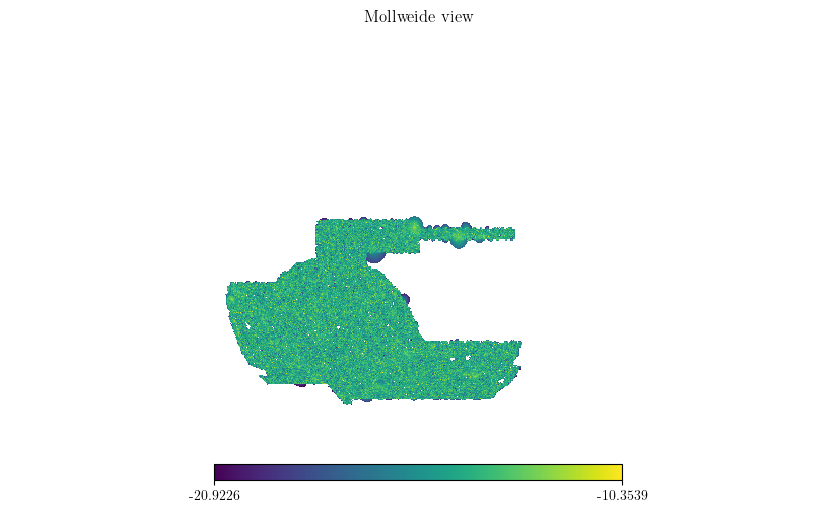

In [5]:
hp.mollview(np.log(ymap_test))




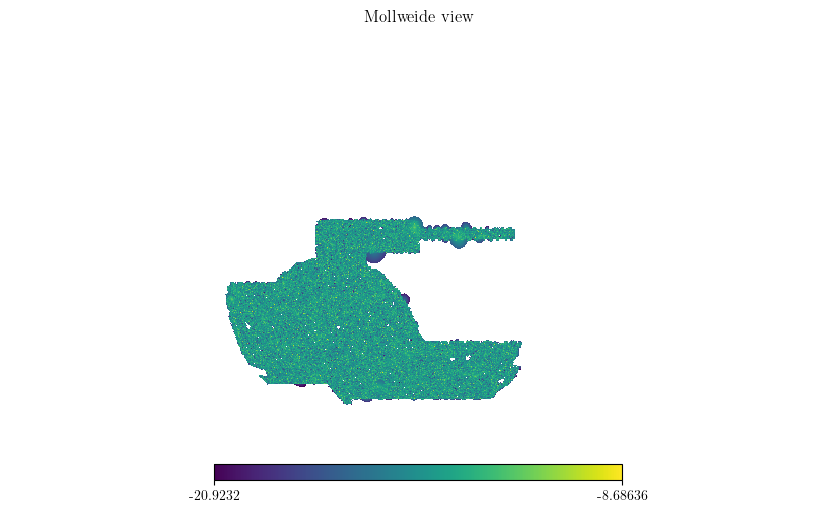

In [6]:
hp.mollview(np.log(ymap_test))




In [4]:
from godmax.get_B12_profile import Battaglia_12_16
B12_test = Battaglia_12_16(halo_params_dict, cosmo_params_dict)



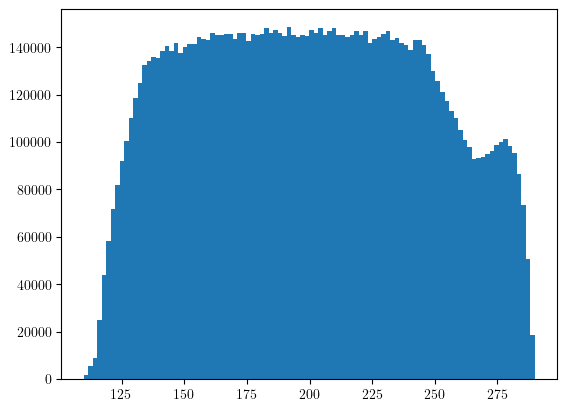

In [20]:
# np.amin(ra_all), np.amax(ra_all)
pl.figure()
_ = pl.hist(ra_all+180., bins=100)


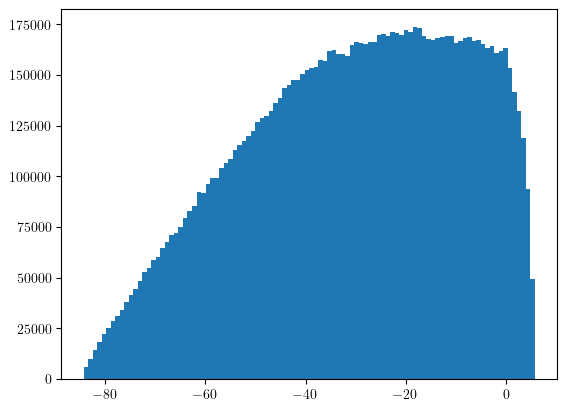

In [19]:
# np.amin(ra_all), np.amax(ra_all)
pl.figure()
_ = pl.hist(dec_all, bins=100)


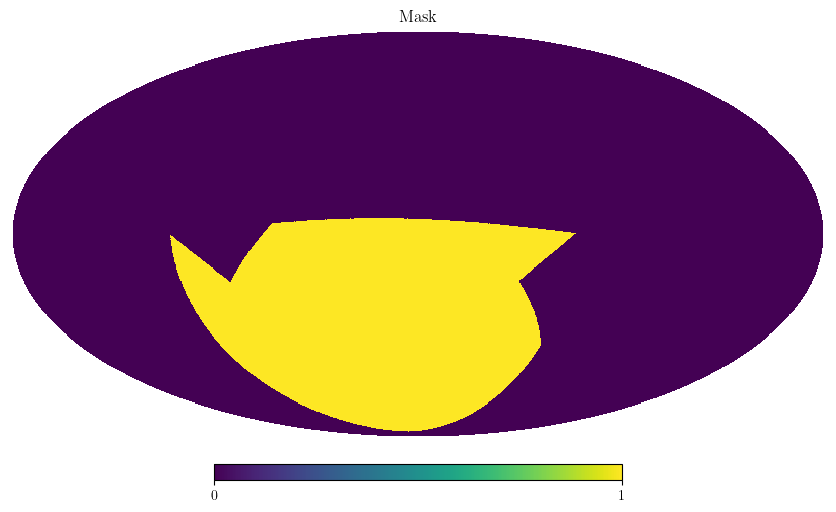

In [22]:
nside = 512
mask = np.zeros(hp.nside2npix(nside))
pix = hp.ang2pix(nside, ra_all, dec_all, lonlat=True)
mask[pix] = 1
hp.mollview(mask, title='Mask', cmap='viridis')
# zh_all = catalog_data['z']
# ra_all = catalog_data['ra']
# dec_all = catalog_data['dec']
# mvir_all = np.array(catalog_data['m200'], dtype=np.float64)


In [24]:
# hp.ang2vec(ra_)
# theta_all, phi_all = hp.lonlat2thetaphi(ra_all, dec_all)

theta_all, phi_all = np.pi / 2.0 - np.radians(dec_all), np.radians(ra_all)




In [29]:
# np.amin(theta_all), np.amax(theta_all)
# np.amin(np.log10(M200c_all))


-inf

In [36]:
nside = 4096
sdir = '/mnt/home/spandey/ceph/GODMAX/notebooks/mock_gen/ymap_cardinal/'
save_ymap_fname = sdir + f'ymap_sim_B12_testv5_nside_{nside}.pkl'
if not os.path.exists(save_ymap_fname):
    halo_ra, halo_dec = ra_all, dec_all
    halo_z = z_all
    halo_m = M200c_all
    indsel = np.where((np.log10(halo_m) > 12.75))[0]
    halo_m = halo_m[indsel]
    halo_ra = halo_ra[indsel]
    halo_dec = halo_dec[indsel]
    halo_z = halo_z[indsel]
    indsel = np.where((halo_z < 0.95))[0]
    halo_m = halo_m[indsel]
    halo_ra = halo_ra[indsel]
    halo_dec = halo_dec[indsel]
    halo_z = halo_z[indsel]
    print('number of halos: ', len(halo_m))
    M_all = halo_m
    ra_all = halo_ra
    dec_all = halo_dec
    z_all = halo_z
    vlos_all = np.zeros_like(z_all)
    nsel = len(M_all)

    nh_max = 1e5
    if nsel > nh_max:
        num_chunks = int(np.ceil(nsel / nh_max))
    else:
        num_chunks = 1


    ymap_test = np.zeros(12*nside**2)
    for i in range(num_chunks):
        print(f'chunk {i+1}/{num_chunks}')
        if i == num_chunks - 1:
            M_all_chunk = M_all[int(i*nh_max):]
            ra_all_chunk = ra_all[int(i*nh_max):]
            dec_all_chunk = dec_all[int(i*nh_max):]
            z_all_chunk = z_all[int(i*nh_max):]
            vlos_all_chunk = vlos_all[int(i*nh_max):]
        else:
            M_all_chunk = M_all[int(i*nh_max):int((i+1)*nh_max)]
            ra_all_chunk = ra_all[int(i*nh_max):int((i+1)*nh_max)]
            dec_all_chunk = dec_all[int(i*nh_max):int((i+1)*nh_max)]
            z_all_chunk = z_all[int(i*nh_max):int((i+1)*nh_max)]
            vlos_all_chunk = vlos_all[int(i*nh_max):int((i+1)*nh_max)]

        mock_params_dict = {}
        mock_params_dict['halo_z'] = jnp.array(z_all_chunk)
        mock_params_dict['halo_ra'] = jnp.array(ra_all_chunk)
        mock_params_dict['halo_dec'] = jnp.array(dec_all_chunk)
        mock_params_dict['halo_M'] = jnp.array(M_all_chunk)
        mock_params_dict['halo_vlos'] = jnp.array(vlos_all_chunk)
        mock_params_dict['nside'] = nside

        halo_cat_scale_fac = 1./(1. + z_all_chunk)

        halo_cat_rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(BCMP_test.cosmo_jax,halo_cat_scale_fac) * 1e9
        mdef_delta=200
        halo_cat_rho_treshold = mdef_delta * halo_cat_rho_c_z


        halo_cat_R200c = (M_all_chunk * 3.0 / 4.0 / jnp.pi / halo_cat_rho_treshold)**(1.0 / 3.0)
        halo_cat_DA = bkgrd.angular_diameter_distance(BCMP_test.cosmo_jax,halo_cat_scale_fac)
        max_paint_R200c_factor = 3.


        # ra_all_np = np.clip(np.array(ra_all_chunk), 0., 360.)
        # dec_all_np = np.clip(np.array(dec_all_chunk), -90., 90.)
        ra_all_np = np.array(ra_all_chunk)
        dec_all_np = np.array(dec_all_chunk)
        z_all_np = np.array(z_all_chunk)
        halo_cat_R200c_np = np.array(halo_cat_R200c)
        halo_cat_DV_np = np.array(halo_cat_DA)
        def process_halo(jhalo):
            vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)

            nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
            nearby_pix = hp.query_disc(mock_params_dict['nside'], vec, nearby_angle)

            nearby_ra, nearby_dec = hp.pix2ang(mock_params_dict['nside'], nearby_pix, lonlat=True)

            def hav(theta):
                return np.sin(theta / 2.) ** 2.

            ra1, dec1 = ra_all_np[jhalo] * np.pi / 180., dec_all_np[jhalo] * np.pi / 180.
            ra2, dec2 = nearby_ra * np.pi / 180., nearby_dec * np.pi / 180.
            theta = 2. * np.arcsin(np.sqrt(hav(dec1 - dec2) + np.cos(dec1) * np.cos(dec2) * hav(ra1 - ra2)))

            physical_distances_jhalo = halo_cat_DV_np[jhalo] * theta

            nearby_pix_array = np.array(nearby_pix)
            distances_pix_array = np.array(physical_distances_jhalo)
            logM_ind_array = np.ones(len(nearby_pix)) * np.log(M_all_chunk[jhalo])
            z_ind_array = np.ones(len(nearby_pix)) * z_all_chunk[jhalo]

            return (nearby_pix_array, distances_pix_array, logM_ind_array, z_ind_array, len(nearby_pix))

        def concatenate_results(results):
            # Pre-compute lengths for each part
            lengths = np.array([len(result[0]) for result in results])
            total_length = lengths.sum()

            # Pre-allocate arrays
            nearby_pix_all = np.empty(total_length, dtype=int)
            distances_pix_all = np.empty(total_length)
            logM_ind_all = np.empty(total_length)
            z_ind_all = np.empty(total_length)

            # Calculate start and end indices
            end_ind_all = np.cumsum(lengths)
            start_ind_all = np.roll(end_ind_all, 1)
            start_ind_all[0] = 0

            # Use array slicing for assignment
            for i, (start, end, result) in enumerate(zip(start_ind_all, end_ind_all, results)):
                nearby_pix_all[start:end] = result[0]
                distances_pix_all[start:end] = result[1]
                logM_ind_all[start:end] = result[2]
                z_ind_all[start:end] = result[3]

            return nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all


        # if __name__ == "__main__":
        with Pool(cpu_count()) as pool:
            results = pool.map(process_halo, range(len(z_all_chunk)))


        nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all = concatenate_results(results)

        mock_params_dict['nearby_pix_all'] = jnp.array(nearby_pix_all)
        mock_params_dict['pix_prop_all'] = jnp.array([np.log(distances_pix_all), z_ind_all, logM_ind_all]).T
        mock_params_dict['start_ind'] = jnp.int32(jnp.array(start_ind_all))
        mock_params_dict['end_ind'] = jnp.int32(jnp.array(end_ind_all))

        mock_map_test = get_mock_map(sim_params_dict, halo_params_dict, mock_params_dict, BCMP_obj=B12_test)

        # find non-finite values and set them to zero
        ymap_test += jnp.nan_to_num(mock_map_test.ymap_final)
        jax.clear_caches()
        


    saved = {}
    saved['ymap_test'] = ymap_test
    pk.dump(saved,open(save_ymap_fname, 'wb'))


else:
    saved = pk.load(open(save_ymap_fname, 'rb'))
    ymap_test = saved['ymap_test']



number of halos:  5106726
chunk 1/52
chunk 2/52
chunk 3/52
chunk 4/52
chunk 5/52
chunk 6/52
chunk 7/52
chunk 8/52
chunk 9/52
chunk 10/52
chunk 11/52
chunk 12/52
chunk 13/52
chunk 14/52
chunk 15/52
chunk 16/52
chunk 17/52
chunk 18/52
chunk 19/52
chunk 20/52
chunk 21/52
chunk 22/52
chunk 23/52
chunk 24/52
chunk 25/52
chunk 26/52
chunk 27/52
chunk 28/52
chunk 29/52
chunk 30/52
chunk 31/52
chunk 32/52
chunk 33/52
chunk 34/52
chunk 35/52
chunk 36/52
chunk 37/52
chunk 38/52
chunk 39/52
chunk 40/52
chunk 41/52
chunk 42/52
chunk 43/52
chunk 44/52
chunk 45/52
chunk 46/52
chunk 47/52
chunk 48/52
chunk 49/52
chunk 50/52
chunk 51/52
chunk 52/52


In [5]:
# mask = np.zeros_like(ymap_test)
# import healpy as hp
import pickle as pk
ymap_test = pk.load(open('/mnt/home/spandey/ceph/GODMAX/notebooks/mock_gen/ymap_cardinal/ymap_sim_B12_testv5_nside_4096.pkl', 'rb'))['ymap_test']
# df = hp.read_map('/mnt/home/spandey/ceph/GODMAX/notebooks/mock_gen/ymap_cardinal/ymap_sim_B12_testv1_nside_4096.pkl')



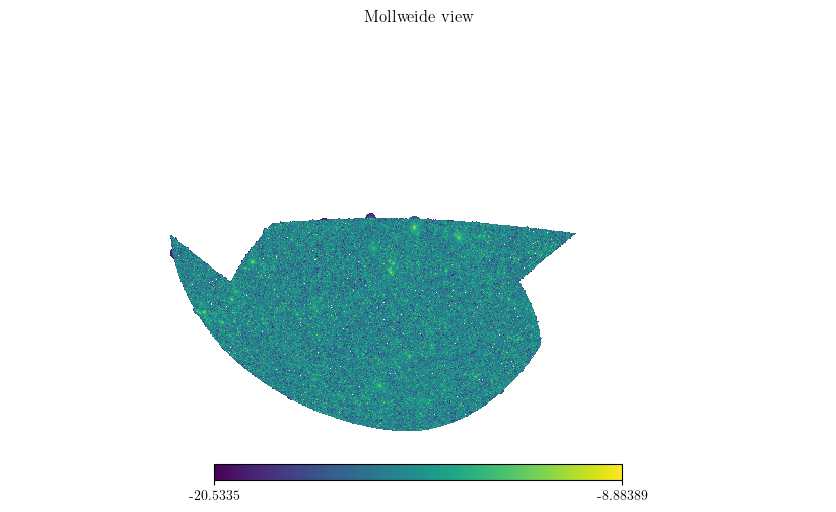

In [6]:
hp.mollview(np.log(ymap_test))




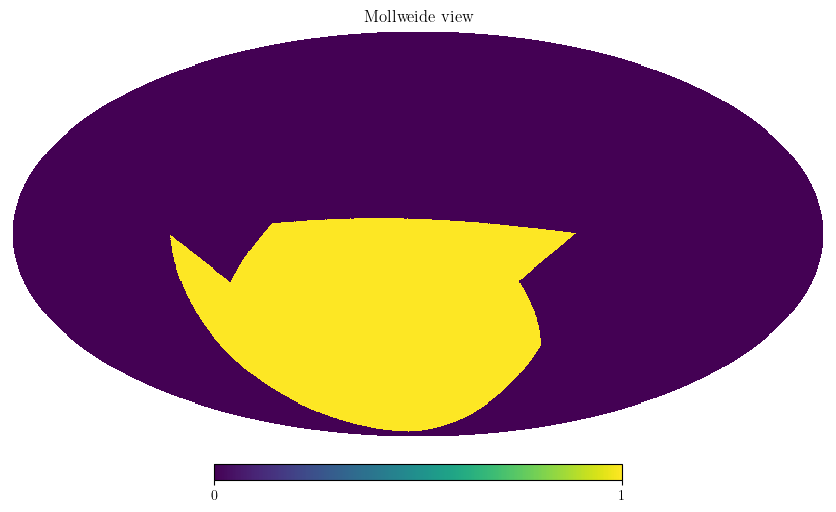

In [7]:
# mask = np.zeros_like(ymap_test)
# mask[ymap_test != 0] = 1
# hp.mollview(mask)
mask = hp.read_map('/mnt/home/spandey/ceph/GODMAX/data/cardinal/mask_tsz_wide.fits')
hp.mollview(mask)


In [ ]:
import pymaster as nmt

# nside = 256
mask = nmt.mask_apodization(mask,
                            0.05, apotype="Smooth")
hp.mollview(mask, coord=['G', 'C'], title='Apodized mask')
# plt.show()



In [8]:
# hp.write_map('/mnt/home/spandey/ceph/GODMAX/data/cardinal/mask_tsz_wide_apodized.fits', mask, overwrite=True)
import pickle as pk
ymap_test = pk.load(open('/mnt/home/spandey/ceph/GODMAX/notebooks/mock_gen/ymap_cardinal/ymap_sim_B12_testv5_nside_4096.pkl', 'rb'))['ymap_test']


mask = hp.read_map('/mnt/home/spandey/ceph/GODMAX/data/cardinal/mask_tsz_wide_apodized.fits')

import pymaster as nmt
f_0 = nmt.NmtField(mask, [ymap_test])

nside = 4096
b = nmt.NmtBin.from_nside_linear(nside, 16)

cl_00 = nmt.compute_full_master(f_0, f_0, b)
ell_arr = b.get_effective_ells()




In [47]:
theta_fwhm = 10.0
sigma_beam = theta_fwhm / np.sqrt(8.0 * np.log(2.0)) / 60.0 * np.pi / 180.0
beam_ell = np.exp(-0.5 * ell_arr * (ell_arr + 1) * sigma_beam**2)



In [24]:
cl_00

array([[4.54785520e-10, 4.43924542e-10, 4.44487120e-10, 4.44411863e-10,
        4.44460184e-10, 4.44421262e-10, 4.44444178e-10, 4.44424701e-10,
        4.44439987e-10, 4.44427565e-10, 4.44431342e-10, 4.44444216e-10,
        4.44440799e-10, 4.44439646e-10, 4.44428225e-10, 4.44434491e-10,
        4.44432777e-10, 4.44434362e-10, 4.44432939e-10, 4.44434786e-10,
        4.44430935e-10, 4.44437188e-10, 4.44436126e-10, 4.44437252e-10,
        4.44440176e-10, 4.44440622e-10, 4.44433689e-10, 4.44432050e-10,
        4.44439717e-10, 4.44437757e-10, 4.44433377e-10, 4.44438087e-10,
        4.44438035e-10, 4.44436806e-10, 4.44433899e-10, 4.44433591e-10,
        4.44435348e-10, 4.44435798e-10, 4.44431551e-10, 4.44435040e-10,
        4.44437121e-10, 4.44437996e-10, 4.44435645e-10, 4.44436532e-10,
        4.44436537e-10, 4.44432834e-10, 4.44435321e-10, 4.44436646e-10,
        4.44436610e-10, 4.44437360e-10, 4.44436771e-10, 4.44436464e-10,
        4.44436649e-10, 4.44436267e-10, 4.44436196e-10, 4.444355

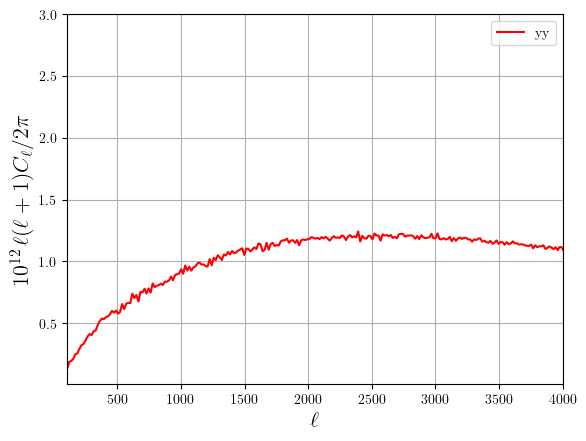

In [14]:

fac = ell_arr * (ell_arr + 1) / (2 * np.pi)
pl.figure()
pl.plot(ell_arr, 1e12 * fac * cl_00[0], 'r-', label='yy')
# pl.plot(ell_arr, (beam_ell**2) * fac * cl_00[0], 'r-', label='yy')
# pl.loglog()
pl.grid()
pl.xlabel('$\\ell$', fontsize=16)
pl.ylabel('$10^{12} \, \ell (\ell + 1) C_\\ell / 2\pi$', fontsize=16)
pl.legend(loc='upper right', ncol=2, labelspacing=0.1)
pl.xlim(100, 4e3)
pl.ylim(1e-2, 3)
pl.show()



KeyboardInterrupt: 

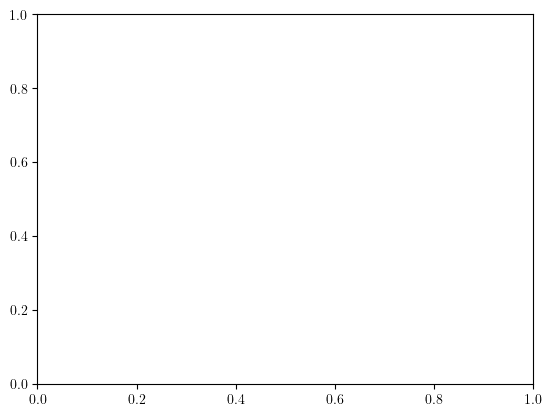

In [ ]:

# pl.figure()
# _ = pl.hist(ymap_test[indsel], bins=100, histtype='step', color='black', lw=2)

